In [21]:
import pandas as pd
import glob

**Task 1 - V2**

In [22]:
# Get all file paths in the folder
files = glob.glob("./PRSA2017_Data_20130301-20170228/*.csv")

print(files)
print(f"Number of files: {len(files)}")

# Read and combine into one DataFrame
df2 = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

['./PRSA2017_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv', './PRSA2017_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv']
Number of files: 12


In [23]:
df2.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [25]:
rows1, cols1 = df2.shape
print(f"Rows: {rows1}, Columns: {cols1}")

Rows: 420768, Columns: 18


---
## Task 2: Data Cleaning

In [26]:
# Identify missing values
missing = df2.isnull().sum()
missing_pct = (missing / len(df2) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

       Missing Count  Missing %
PM2.5           8739       2.08
PM10            6449       1.53
SO2             9021       2.14
NO2            12116       2.88
CO             20701       4.92
O3             13277       3.16
TEMP             398       0.09
PRES             393       0.09
DEWP             403       0.10
RAIN             390       0.09
wd              1822       0.43
WSPM             318       0.08


In [27]:
# This is hourly time series data, so interpolation is the correct approach.
# Linear interpolation estimates each missing value from the readings immediately
# before and after it — much more realistic than injecting a global median.
#
# We sort by station + datetime first so interpolation stays within each
# station's own time sequence and doesn't bleed across stations.

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Build a datetime column so we can sort chronologically per station
df2['datetime'] = pd.to_datetime(df2[['year', 'month', 'day', 'hour']])
df2 = df2.sort_values(['station', 'datetime']).reset_index(drop=True)

# Interpolate within each station group independently
df2[numeric_cols] = (
    df2.groupby('station', group_keys=False)[numeric_cols]
    .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
)

# Report how many nulls remain after interpolation
remaining = df2[numeric_cols].isnull().sum()
print("Remaining nulls after interpolation:")
print(remaining[remaining > 0] if remaining.sum() > 0 else "None — all filled successfully")

df2.head()

Remaining nulls after interpolation:
None — all filled successfully


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [28]:
# Wind direction (wd) is categorical — interpolation doesn't apply.
# Forward-fill then backward-fill: carry the last known direction forward,
# and fill any leading nulls backward. Done per station to avoid cross-station bleed.
df2['wd'] = (
    df2.groupby('station', group_keys=False)['wd']
    .apply(lambda g: g.ffill().bfill())
)

# Verify no missing values remain across all cleaned columns
total_missing = df2[numeric_cols + ['wd']].isnull().sum().sum()
print(f"Total remaining missing values: {total_missing}")
print("All cleaned successfully!" if total_missing == 0 else "Some nulls remain — check above.")

Total remaining missing values: 0
All cleaned successfully!


In [29]:
# Safety net: drop any rows where PM2.5 is still null after interpolation.
# This would only happen if an entire station had no valid PM2.5 readings
# at the start or end of the time series (edge case with no neighbours to interpolate from).
before = len(df2)
df2 = df2.dropna(subset=['PM2.5'])
after = len(df2)
print(f"Rows removed: {before - after}")
print(f"Rows remaining: {after}")

Rows removed: 0
Rows remaining: 420768


---
## Task 3: Basic Statistical Analysis

In [30]:
# Statistical summary for all pollutant columns
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

stats = pd.DataFrame({
    'Mean':   df2[pollutants].mean().round(2),
    'Median': df2[pollutants].median().round(2),
    'Min':    df2[pollutants].min().round(2),
    'Max':    df2[pollutants].max().round(2),
    'Std Dev': df2[pollutants].std().round(2)
})

print(stats)

          Mean  Median     Min      Max  Std Dev
PM2.5    79.84    55.0    2.00    999.0    80.95
PM10    104.91    82.0    2.00    999.0    92.43
SO2      15.91     7.0    0.29    500.0    21.90
NO2      50.60    43.0    1.03    290.0    35.17
CO     1235.68   900.0  100.00  10000.0  1161.79
O3       57.24    44.0    0.21   1071.0    57.14


---
## Task 4: Data Filtering

In [31]:
# Filter data by a specific station — Dongsi
station_name = 'Dongsi'
df_station = df2[df2['station'] == station_name]

print(f"Station: {station_name}")
print(f"Total records: {len(df_station)}")
df_station.head()

Station: Dongsi
Total records: 35064


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
105192,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00
105193,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00
105194,3,2013,3,1,2,7.0,7.0,4.0,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00
105195,4,2013,3,1,3,3.0,3.0,5.0,18.0,250.0,72.0,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00
105196,5,2013,3,1,4,3.0,3.0,7.0,21.5,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00


In [32]:
# Calculate average pollution levels per station
avg_pollution = df2.groupby('station')[pollutants].mean().round(2)
avg_pollution = avg_pollution.sort_values('PM2.5', ascending=False)

print("Average pollution levels by station (sorted by PM2.5):")
print(avg_pollution)

Average pollution levels by station (sorted by PM2.5):
               PM2.5    PM10    SO2    NO2       CO     O3
station                                                   
Dongsi         86.14  110.35  18.51  53.95  1331.91  57.70
Nongzhanguan   85.08  109.38  18.76  58.10  1327.77  58.43
Wanshouxigong  85.07  112.51  17.36  55.50  1373.62  55.92
Gucheng        84.07  119.26  15.71  55.82  1338.10  58.00
Wanliu         83.47  110.71  18.41  65.67  1328.76  46.91
Guanyuan       82.90  109.37  17.61  58.14  1258.33  54.82
Aotizhongxin   82.54  110.21  17.46  59.07  1264.69  55.33
Tiantan        82.03  106.54  14.51  53.26  1305.33  56.15
Shunyi         79.44   99.27  13.45  44.09  1197.90  54.22
Changping      70.99   94.79  14.94  44.21  1156.99  57.98
Huairou        69.50   92.42  12.45  32.08  1019.67  60.87
Dingling       66.85   84.11  11.80  27.30   925.11  70.53


---
## Task 5: Data Visualization

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

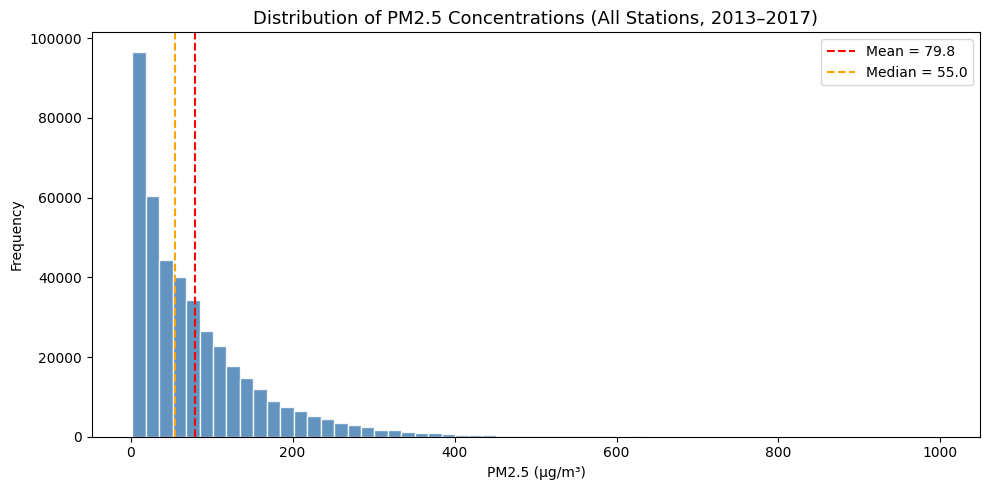

In [34]:
# Histogram of PM2.5
plt.figure(figsize=(10, 5))
plt.hist(df2['PM2.5'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Distribution of PM2.5 Concentrations (All Stations, 2013–2017)', fontsize=13)
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.axvline(df2['PM2.5'].mean(), color='red', linestyle='--', label=f"Mean = {df2['PM2.5'].mean():.1f}")
plt.axvline(df2['PM2.5'].median(), color='orange', linestyle='--', label=f"Median = {df2['PM2.5'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

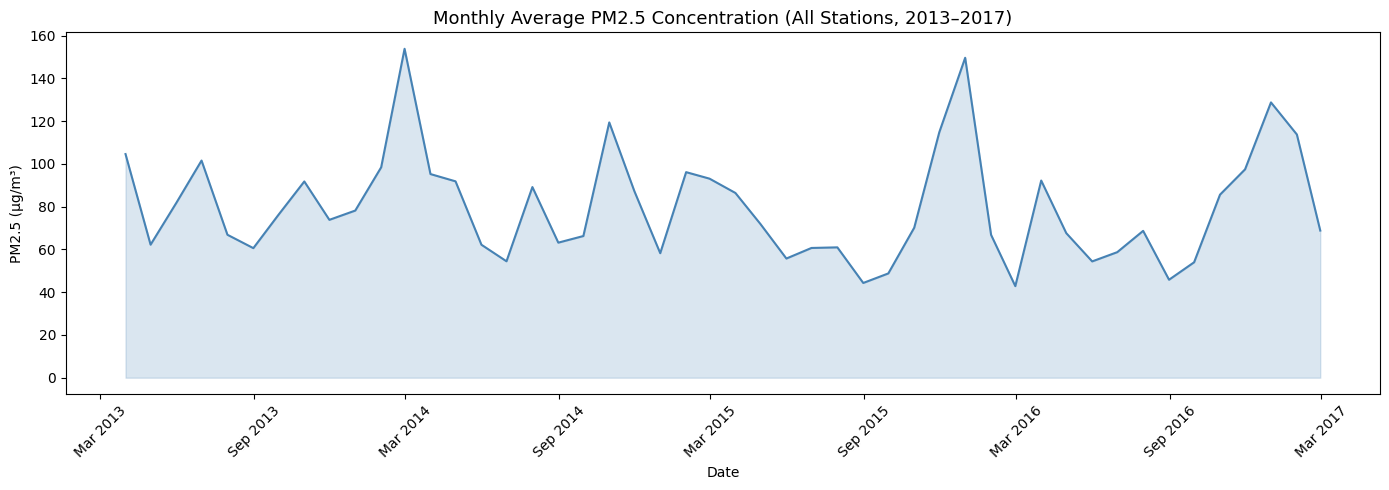

In [35]:
# Line plot of PM2.5 over time (monthly average across all stations)
df2['date'] = pd.to_datetime(df2[['year', 'month', 'day']])
monthly_avg = df2.groupby('date')['PM2.5'].mean().resample('ME').mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg.index, monthly_avg.values, color='steelblue', linewidth=1.5)
plt.fill_between(monthly_avg.index, monthly_avg.values, alpha=0.2, color='steelblue')
plt.title('Monthly Average PM2.5 Concentration (All Stations, 2013–2017)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

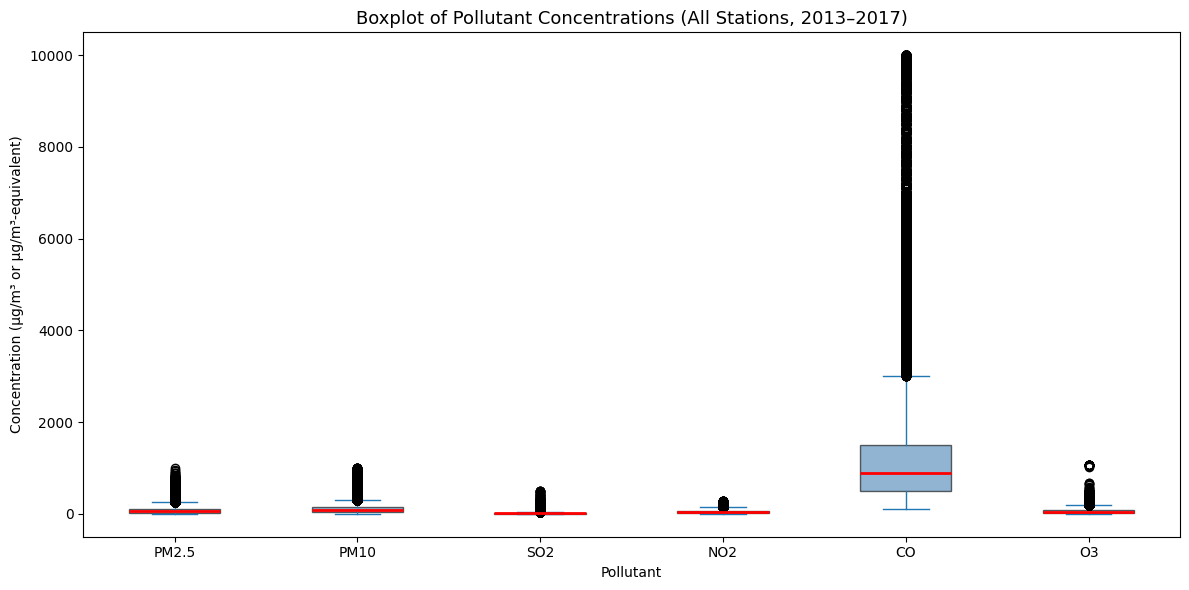

In [36]:
# Boxplot of pollutant concentrations
fig, ax = plt.subplots(figsize=(12, 6))
df2[pollutants].plot(kind='box', ax=ax, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
ax.set_title('Boxplot of Pollutant Concentrations (All Stations, 2013–2017)', fontsize=13)
ax.set_ylabel('Concentration (µg/m³ or µg/m³-equivalent)')
ax.set_xlabel('Pollutant')
plt.tight_layout()
plt.show()

---
## Task 6: Correlation Analysis

In [37]:
# Correlation of all numeric variables with PM2.5
numeric_features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
correlations = df2[numeric_features + ['PM2.5']].corr()['PM2.5'].drop('PM2.5').sort_values(ascending=False)

print("Correlation with PM2.5:")
print(correlations.round(3))
print(f"\nMost positively correlated: {correlations.idxmax()} ({correlations.max():.3f})")
print(f"Most negatively correlated: {correlations.idxmin()} ({correlations.min():.3f})")

Correlation with PM2.5:
PM10    0.879
CO      0.780
NO2     0.664
SO2     0.478
DEWP    0.113
PRES    0.020
RAIN   -0.014
TEMP   -0.132
O3     -0.150
WSPM   -0.271
Name: PM2.5, dtype: float64

Most positively correlated: PM10 (0.879)
Most negatively correlated: WSPM (-0.271)


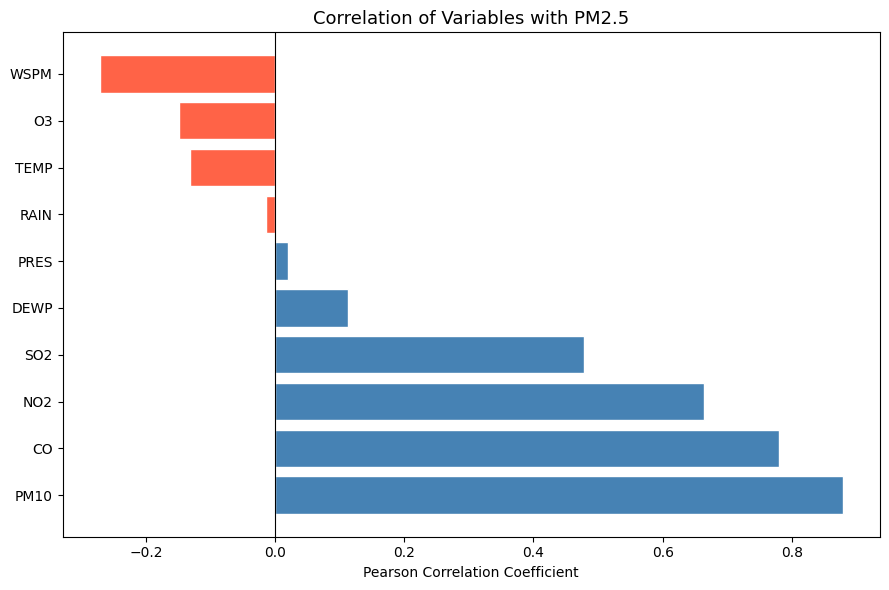

In [38]:
# Visualise correlations with a horizontal bar chart
colors = ['steelblue' if v >= 0 else 'tomato' for v in correlations]

plt.figure(figsize=(9, 6))
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Variables with PM2.5', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

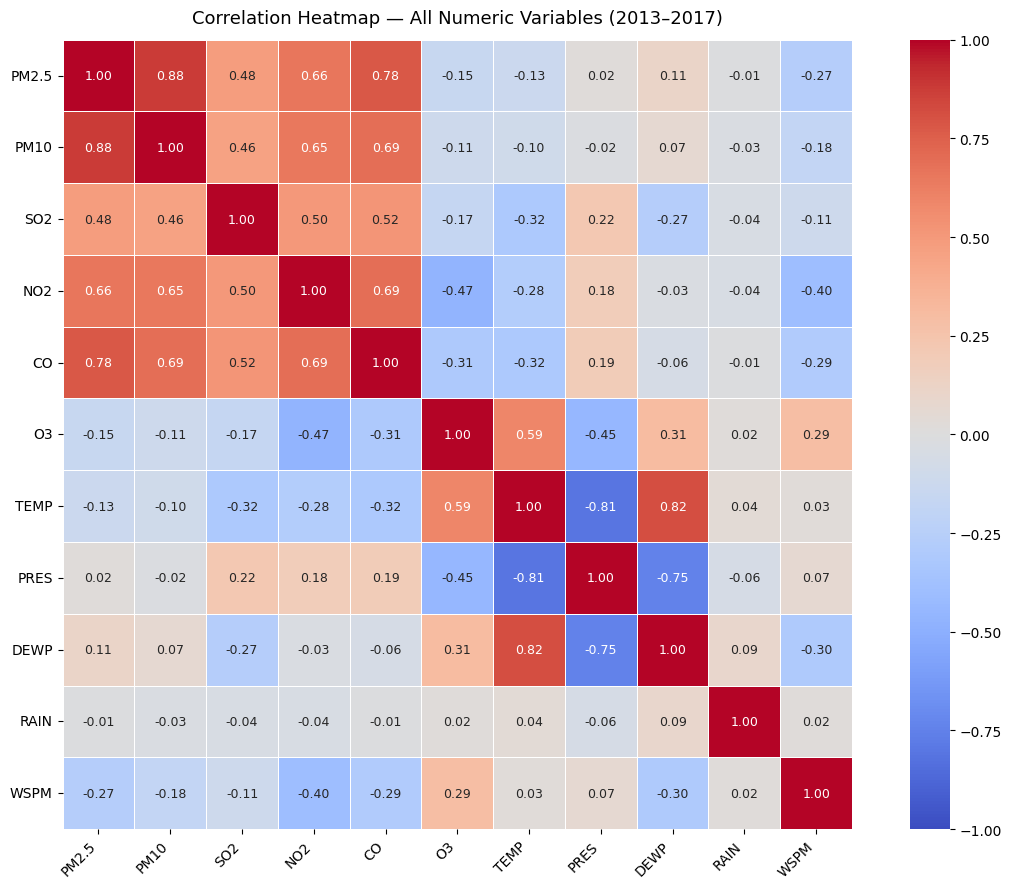

In [39]:
# Correlation heatmap — all numeric variables
import seaborn as sns

all_numeric = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = df2[all_numeric].corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,          # show correlation values in each cell
    fmt='.2f',           # 2 decimal places
    cmap='coolwarm',     # blue = negative, red = positive
    center=0,            # white at zero
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap — All Numeric Variables (2013–2017)', fontsize=13, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Average PM2.5 by temperature range (°C):
temp_bin
<-10     22.46
-10–0    98.74
0–10     88.38
10–20    76.11
20–30    70.54
>30      59.98
Name: PM2.5, dtype: float64


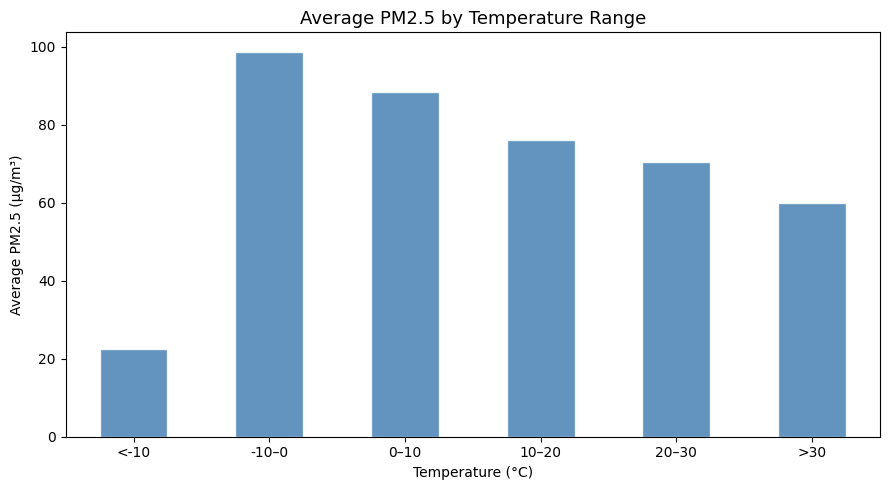


Conclusion: PM2.5 is notably higher in cold temperatures (winter months),
consistent with heating emissions and reduced atmospheric mixing.
Pearson correlation with TEMP: -0.132 (negative — colder = more pollution)


In [40]:
# Does temperature affect pollution levels?
# Create temperature bins and compute mean PM2.5 per bin
df2['temp_bin'] = pd.cut(df2['TEMP'], bins=[-30, -10, 0, 10, 20, 30, 42],
                         labels=['<-10', '-10–0', '0–10', '10–20', '20–30', '>30'])

temp_pm25 = df2.groupby('temp_bin', observed=True)['PM2.5'].mean().round(2)
print("Average PM2.5 by temperature range (°C):")
print(temp_pm25)

plt.figure(figsize=(9, 5))
temp_pm25.plot(kind='bar', color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Average PM2.5 by Temperature Range', fontsize=13)
plt.xlabel('Temperature (°C)')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nConclusion: PM2.5 is notably higher in cold temperatures (winter months),")
print("consistent with heating emissions and reduced atmospheric mixing.")
print(f"Pearson correlation with TEMP: {df2['TEMP'].corr(df2['PM2.5']):.3f} (negative — colder = more pollution)")